In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Advertising Budget and Sales.csv')   # adjust filename to match exactly what you downloaded
print(df.shape)
df.head()

(200, 5)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


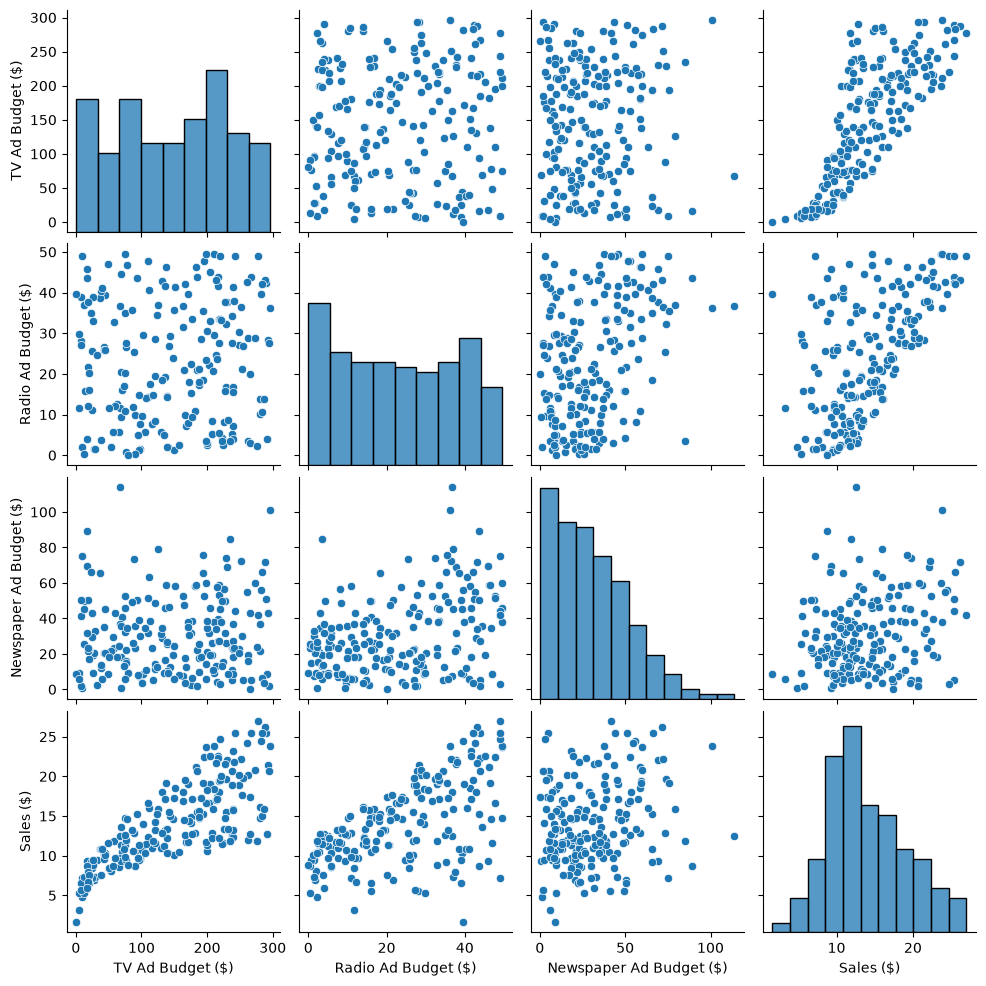

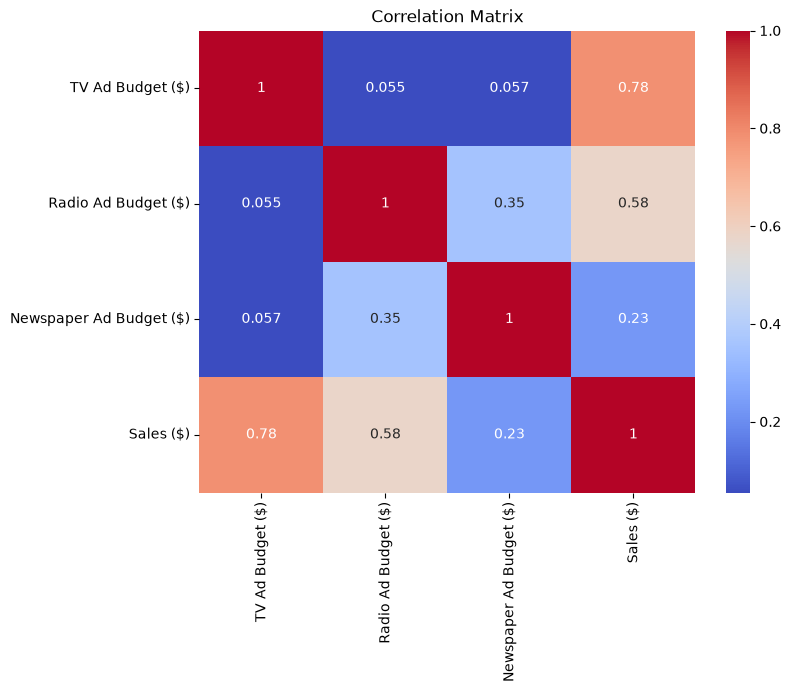

In [3]:
sns.pairplot(df)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

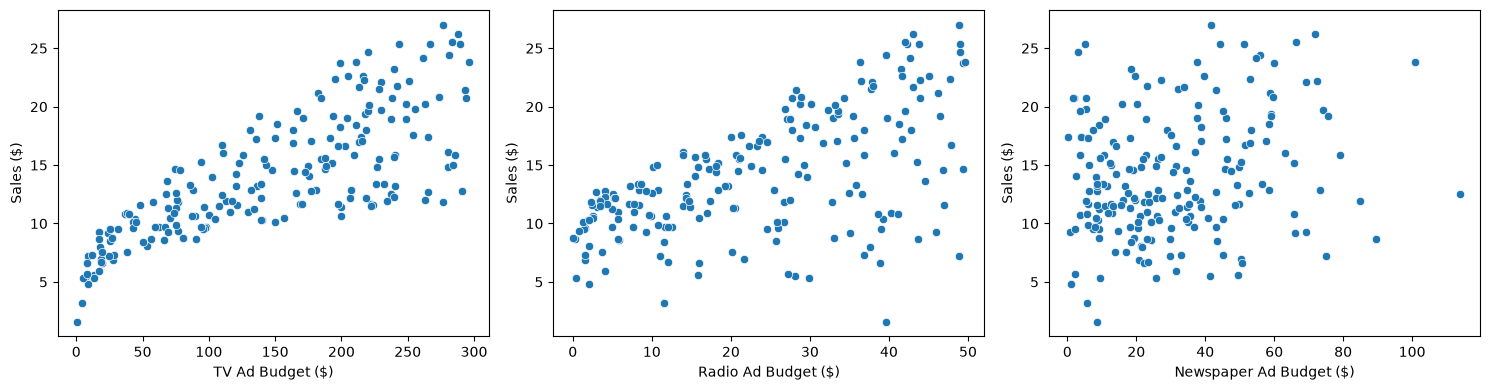

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(x='TV Ad Budget ($)', y='Sales ($)', data=df, ax=axes[0])
sns.scatterplot(x='Radio Ad Budget ($)', y='Sales ($)', data=df, ax=axes[1])
sns.scatterplot(x='Newspaper Ad Budget ($)', y='Sales ($)', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 1.4607567168117603
RMSE: 1.78159966153345
R²: 0.899438024100912


In [8]:
coefficients = pd.Series(model_lr.coef_, index=X.columns)
print(coefficients)
print("Intercept:", model_lr.intercept_)

TV Ad Budget ($)           0.044730
Radio Ad Budget ($)        0.189195
Newspaper Ad Budget ($)    0.002761
dtype: float64
Intercept: 2.979067338122629


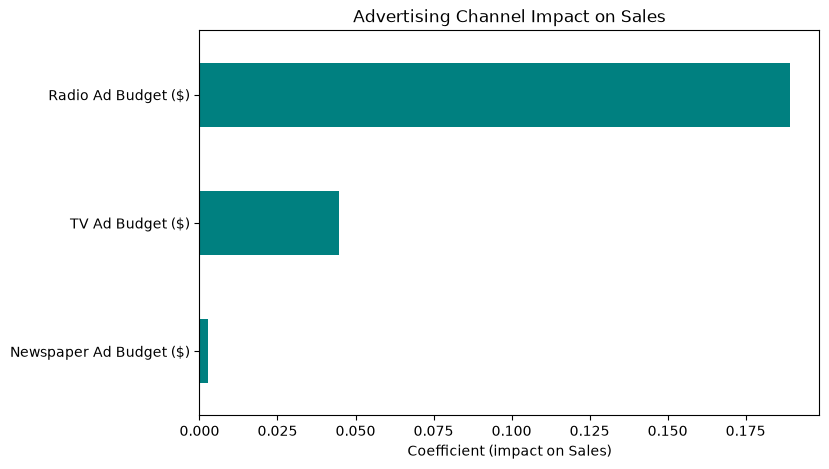

In [9]:
plt.figure(figsize=(8,5))
coefficients.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Coefficient (impact on Sales)')
plt.title('Advertising Channel Impact on Sales')
plt.show()

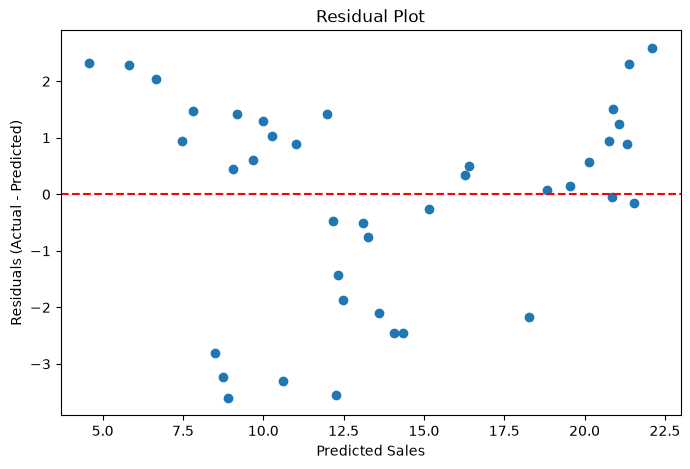

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

### Coefficient Interpretation
The model's coefficients are:
- **TV**:  — the strongest positive driver of sales
- **Radio**:  — a moderate positive effect
- **Newspaper**:  — negligible/near-zero effect

This confirms the pattern seen in the correlation matrix and scatter plots: 
**TV advertising has the highest impact on sales**, Radio contributes moderately, 
and Newspaper advertising shows almost no measurable relationship with sales in 
this dataset. 

### Business Recommendation
Marketing budget should be prioritized toward TV advertising, followed by Radio. 
Newspaper spend appears to yield minimal return in this dataset and could be 
reduced or reallocated toward the higher-performing channels.

In [11]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))

MAE: 0.6203249999999988
RMSE: 0.7687170968568338
R²: 0.9812782416450916
